### Detecting anomalies/outliers in data, case Titanic

In [104]:
# importing modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import the DBSCAN - algorithm + scaler
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MinMaxScaler

In [105]:
df = sns.load_dataset("titanic")
df

# just a quick demonstration, so we will drop all NaN values
# this results in losing 70% of the data, see the logistic regression
# example how to do this properly without losing most of the data
df = df.dropna()

In [106]:
# let's only select two variables so we can easily visualize the result
df = df[['age', 'fare']]

<Axes: xlabel='age', ylabel='fare'>

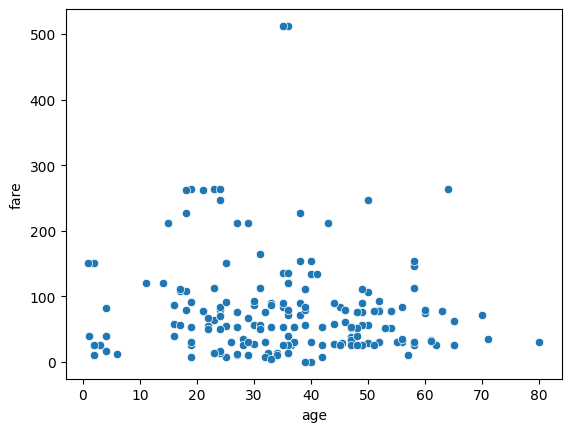

In [107]:
sns.scatterplot(x="age", y="fare", data=df)

### DBSCAN requires scaled values

In [108]:
# initialize scaler
scaler = MinMaxScaler()

scaled_df = scaler.fit_transform(df)

In [109]:
# use DBSCAN
outliers = DBSCAN(
    eps=0.125,
    metric="euclidean",
    min_samples=5,
    n_jobs=-1
)

# get the outliers based on DBSCAN
clusters = outliers.fit_predict(scaled_df)
clusters

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0, -1, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
       -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
       -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

In [110]:
df['cluster'] = clusters

<Axes: xlabel='age', ylabel='fare'>

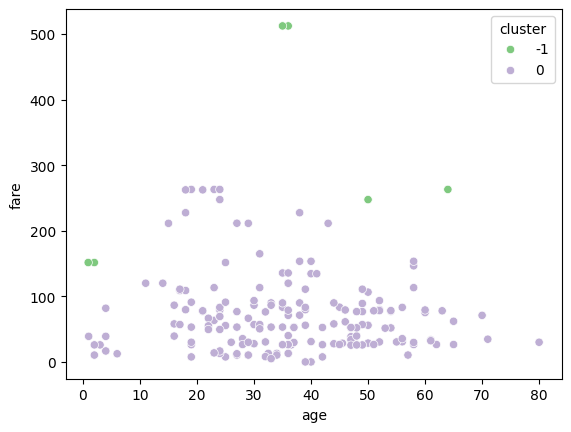

In [ ]:
# visualize the clusters or the anomalies in this case
# -1 implies anomaly/outlier in this context usually
sns.scatterplot(x="age", y="fare", hue="cluster", data=df, palette="Accent")

### To find a rough estimation of a suitable epsilon, we can use this plot:

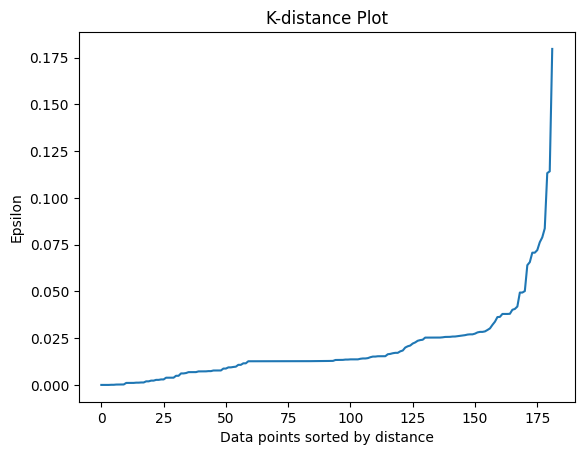

In [112]:
scaler_epsilon = MinMaxScaler()
df[['age', 'fare']] = scaler_epsilon.fit_transform(df[['age', 'fare']])

from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=2)
neighbors = nn.fit(df[['age', 'fare']])

distances, indices = neighbors.kneighbors(df[['age', 'fare']] )

# plotting the epsilon plot

distances = np.sort(distances, axis=0)
distances = distances[:, 1]

plt.plot(distances)
plt.title("K-distance Plot")
plt.xlabel("Data points sorted by distance")
plt.ylabel("Epsilon")
plt.show()